# Sentiment Analysis Using NLP

Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

Dataset Loading

In [ ]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Checking the Dataset

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


Checking a Sample Review

In [ ]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

Checking Dataset Size

In [ ]:
print("Training samples:", len(dataset["train"]))
print("Testing samples:", len(dataset["test"]))

Training samples: 25000
Testing samples: 25000


Convert Dataset into dataframe

In [ ]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


Checking Dataset Columns

In [ ]:
print(train_df.columns)

Index(['text', 'label'], dtype='object')


Checking Sentiment Distribution

In [ ]:
print(train_df["label"].value_counts())

label
0    12500
1    12500
Name: count, dtype: int64


Looking at positive and Negation Reviews

In [ ]:
print("Negative review:")
print(train_df[train_df["label"] == 0]["text"].iloc[0])

print("\nPositive review:")
print(train_df[train_df["label"] == 1]["text"].iloc[0])

Negative review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and

Text Preprocessing

In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

Function of Text Cleaning

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()

    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

Checking the Preprocessing

In [ ]:
sample_review = train_df["text"].iloc[0]

print("Original review:")
print(sample_review)

print("\nCleaned review:")
print(clean_text(sample_review))

Original review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and

Applying Preprocessing to the Dataset

In [ ]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

Checking the Cleaned Data

In [ ]:
print(train_df[["text", "clean_text", "label"]].head())

                                                text  \
0  I rented I AM CURIOUS-YELLOW from my video sto...   
1  "I Am Curious: Yellow" is a risible and preten...   
2  If only to avoid making this type of film in t...   
3  This film was probably inspired by Godard's Ma...   
4  Oh, brother...after hearing about this ridicul...   

                                          clean_text  label  
0  rented curious yellow video store controversy ...      0  
1  curious yellow risible pretentious steaming pi...      0  
2  avoid making type film future film interesting...      0  
3  film probably inspired godard masculin f minin...      0  
4  oh brother hearing ridiculous film umpteen yea...      0  


Feature Extraction using TF-IDF



In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df["clean_text"])
X_test = vectorizer.transform(test_df["clean_text"])

In [ ]:
y_train = train_df["label"]
y_test = test_df["label"]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (25000, 5000)
Testing data shape: (25000, 5000)


Training the Logistic Regression Model

In [19]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Predictions

In [20]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 1 0 1 0 0 0]


Model Evaluation

In [21]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.8792
Precision: 0.8773
Recall   : 0.8817
F1-Score : 0.8795


Classification Report

In [22]:
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88     12500
    Positive       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



Checking some predictions

In [23]:
for i in range(5):
    print("Review:", test_df["text"].iloc[i][:200])
    print("Actual sentiment:", "Positive" if y_test.iloc[i] == 1 else "Negative")
    print("Predicted sentiment:", "Positive" if y_pred[i] == 1 else "Negative")
    print("-" * 50)

Review: I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Bab
Actual sentiment: Negative
Predicted sentiment: Negative
--------------------------------------------------
Review: Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell 
Actual sentiment: Negative
Predicted sentiment: Negative
--------------------------------------------------
Review: its a totally average film with a few semi-alright action sequences that make the plot seem a little better and remind the viewer of the classic van dam films. parts of the plot don't make sense and s
Actual sentiment: Negative
Predicted sentiment: Negative
--------------------------------------------------
Review: STAR RATING: ***** Saturday Night **** Fr

Confusion Matrix

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10959  1541]
 [ 1479 11021]]


Confusion Matrix Visualization

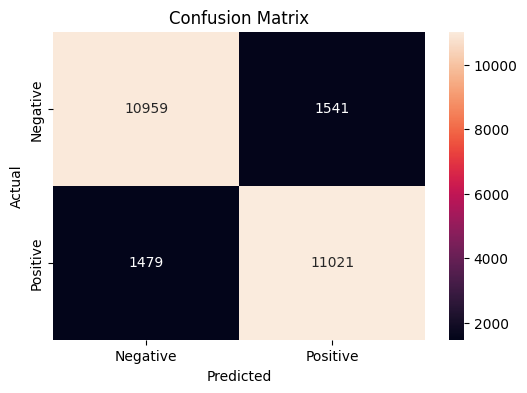

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Model Performance Analysis

The model achieved 87.92% accuracy on the test data. The precision was 87.73%, recall was 88.17%, and the F1-score was 87.95%.

The confusion matrix also shows that the model performed almost equally well for positive and negative reviews. Some reviews were classified incorrectly, but overall the results were good.

## Insights and Recommendations

The model gave a good result on the test data. It achieved 87.92% accuracy, which means that most of the reviews were classified correctly. The precision was 87.73%, recall was 88.17%, and the F1-score was 87.95%.

From the confusion matrix, we can see that the model correctly classified 10,959 negative reviews and 11,021 positive reviews. Some reviews were classified incorrectly, but overall the model performed almost equally well for both positive and negative reviews.

### Practical Applications

This type of sentiment analysis can be useful in different areas:

- **Customer feedback:** It can help businesses understand whether customers are happy or unhappy.
- **Product reviews:** It can be used to check the overall sentiment of product reviews.
- **Marketing:** Companies can use customer opinions to see how people respond to their products or campaigns.
- **Customer support:** Negative feedback can be identified more quickly so it can be handled.
- **Social media:** It can help in understanding people's opinions and reactions.

### Possible Improvements

The model can be improved by trying other machine learning models and comparing their results. We can also tune the model settings to get better performance. In the future, more advanced NLP methods like word embeddings or transformer models can also be used.

## Conclusion

In this project, I built a simple sentiment analysis model using NLP. The movie reviews were cleaned and prepared before converting them into numerical features using TF-IDF.

I used Logistic Regression to classify the reviews into positive and negative sentiments. The model achieved 87.92% accuracy on the test data, which shows that it was able to classify most of the reviews correctly.

Overall, this project helped me understand the basic NLP workflow, starting from text preprocessing and feature extraction to model training and evaluation.